In [ ]:
from google.colab import files # Import the files module from Google Colab to handle file uploads
files.upload() # Prompt the user to upload a file (e.g., kaggle.json)

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"tj2024","key":"4c0d79c2406247cec56c92e658f2c8bf"}'}

In [ ]:
!mkdir -p ~/.kaggle # Create a hidden directory for Kaggle configuration if it doesn't exist
!cp kaggle.json ~/.kaggle/ # Copy the uploaded kaggle.json file to the Kaggle configuration directory
!chmod 600 ~/.kaggle/kaggle.json # Set restrictive permissions on the kaggle.json file for security

In [ ]:
!pip install -q kaggle # Install the Kaggle API client library silently

In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia # Download the specified Kaggle dataset

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:29<00:00, 290MB/s]
100% 2.29G/2.29G [00:29<00:00, 82.7MB/s]


In [ ]:
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data # Unzip the downloaded dataset into a new directory named 'chest_xray_data'

In [ ]:
import os # Import the os module for interacting with the operating system
data_dir = "chest_xray_data/chest_xray" # Define the base directory for the dataset
print(os.listdir(data_dir)) # List the contents of the dataset directory to inspect its structure

['chest_xray', 'val', 'test', 'train', '__MACOSX']


In [ ]:
import os # For interacting with the operating system (e.g., file paths)
import copy # For creating deep copies of objects (e.g., model weights)
import numpy as np # For numerical operations, especially with arrays
import matplotlib.pyplot as plt # For plotting and visualization
from PIL import Image # For opening and manipulating image files

import torch # The main PyTorch library for deep learning
import torch.nn as nn # Neural network modules (e.g., layers)
import torch.optim as optim # Optimization algorithms (e.g., Adam, SGD)
from torch.utils.data import DataLoader, random_split # Utilities for data loading and splitting
from torchvision import datasets, transforms, models # Datasets, image transformations, and pre-trained models

from tqdm import tqdm # For displaying progress bars during training/evaluation

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Determine if CUDA (GPU) is available, otherwise use CPU
print("Using device:", device) # Print the device being used for computation

Using device: cuda


In [ ]:
transform = transforms.Compose([ # Define a sequence of image transformations
    transforms.Resize((224, 224)), # Resize images to 224x224 pixels
    transforms.Grayscale(num_output_channels=3), # Convert grayscale images to 3 channels (required by ResNet)
    transforms.ToTensor(), # Convert PIL image to PyTorch tensor
    transforms.Normalize([0.485, 0.456, 0.406], # Normalize pixel values using ImageNet mean and standard deviation
                         [0.229, 0.224, 0.225]) # These are standard values for pre-trained models
])

In [ ]:
data_dir = "chest_xray_data/chest_xray" # Define the root directory for the dataset
full_train = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform) # Load the full training dataset with transformations
test_data = datasets.ImageFolder(os.path.join(data_dir, "test"), transform=transform) # Load the test dataset with transformations

train_size = int(0.8 * len(full_train)) # Calculate the size for the training split (80%)
val_size = len(full_train) - train_size # Calculate the size for the validation split (remaining 20%)

train_data, val_data = random_split(full_train, [train_size, val_size]) # Split the full training data into training and validation sets

train_loader = DataLoader(train_data, batch_size=32, shuffle=True) # Create a DataLoader for the training set, shuffling data
val_loader = DataLoader(val_data, batch_size=32, shuffle=False) # Create a DataLoader for the validation set, no shuffling
test_loader = DataLoader(test_data, batch_size=32, shuffle=False) # Create a DataLoader for the test set, no shuffling

class_names = full_train.classes # Get the class names (e.g., 'NORMAL', 'PNEUMONIA')
print("Classes:", class_names) # Print the identified class names

Classes: ['NORMAL', 'PNEUMONIA']


In [ ]:
from torchsummary import summary
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Ensure device is defined if not already

model = models.resnet18(weights="IMAGENET1K_V1") # Load a pre-trained ResNet-18 model with ImageNet weights

num_ftrs = model.fc.in_features # Get the number of input features for the final fully connected layer
model.fc = nn.Sequential( # Replace the original final layer with a custom sequential layer
    nn.Dropout(0.5), # Add a Dropout layer for regularization (to prevent overfitting)
    nn.Linear(num_ftrs, 2) # Add a new linear layer with 2 output features (for binary classification)
) # 2 classes: NORMAL, PNEUMONIA

model = model.to(device) # Move the entire model to the specified device (GPU/CPU)

summary(model, (3,224,224))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 157MB/s]


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [ ]:
model = models.resnet18(weights="IMAGENET1K_V1") # Load a pre-trained ResNet-18 model with ImageNet weights

num_ftrs = model.fc.in_features # Get the number of input features for the final fully connected layer
model.fc = nn.Sequential( # Replace the original final layer with a custom sequential layer
    nn.Dropout(0.5), # Add a Dropout layer for regularization (to prevent overfitting)
    nn.Linear(num_ftrs, 2) # Add a new linear layer with 2 output features (for binary classification)
) # 2 classes: NORMAL, PNEUMONIA

model = model.to(device) # Move the entire model to the specified device (GPU/CPU)

In [ ]:
criterion = nn.CrossEntropyLoss() # Define the loss function: Cross-Entropy Loss for classification
optimizer = optim.Adam(model.parameters(), lr=1e-4) # Define the optimizer: Adam with a learning rate of 0.0001

In [ ]:
def train_one_epoch(model, loader, device):
    model.train() # Set the model to training mode (enables dropout, batch norm updates)
    running_loss, running_corrects, total = 0, 0, 0 # Initialize metrics for the epoch

    for inputs, labels in tqdm(loader, desc="Training"): # Iterate over batches with a progress bar
        inputs, labels = inputs.to(device), labels.to(device) # Move input data and labels to the specified device

        optimizer.zero_grad() # Zero the gradients before backpropagation
        outputs = model(inputs) # Perform a forward pass

        loss = criterion(outputs, labels) # Calculate the loss
        loss.backward() # Perform backpropagation to compute gradients
        optimizer.step() # Update model parameters based on gradients

        _, preds = torch.max(outputs, 1) # Get the predicted class (index of max log-probability)
        running_loss += loss.item() # Accumulate batch loss
        running_corrects += torch.sum(preds == labels.data) # Accumulate correct predictions
        total += labels.size(0) # Accumulate total samples processed

    return running_loss / len(loader), (running_corrects.double() / total).item() # Return average loss and accuracy


def evaluate(model, loader, device):
    model.eval() # Set the model to evaluation mode (disables dropout, fixes batch norm)
    running_loss, running_corrects, total = 0, 0, 0 # Initialize metrics for evaluation

    with torch.no_grad(): # Disable gradient calculation for efficiency during evaluation
        for inputs, labels in tqdm(loader, desc="Evaluating"): # Iterate over batches with a progress bar
            inputs, labels = inputs.to(device), labels.to(device) # Move data to the specified device

            outputs = model(inputs) # Perform a forward pass
            loss = criterion(outputs, labels) # Calculate the loss

            _, preds = torch.max(outputs, 1) # Get the predicted class
            running_loss += loss.item() # Accumulate batch loss
            running_corrects += torch.sum(preds == labels.data) # Accumulate correct predictions
            total += labels.size(0) # Accumulate total samples processed

    return running_loss / len(loader), (running_corrects.double() / total).item() # Return average loss and accuracy

In [ ]:
epochs = 2 # Set the number of training epochs
best_model_wts = copy.deepcopy(model.state_dict()) # Initialize best model weights with current model's state
best_val_acc = 0.0 # Initialize best validation accuracy

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []} # Dictionary to store training history

for epoch in range(epochs): # Loop through each epoch
    print(f"\n========== Epoch {epoch+1}/{epochs} ==========") # Print epoch number

    train_loss, train_acc = train_one_epoch(model, train_loader, device) # Train for one epoch
    val_loss, val_acc = evaluate(model, val_loader, device) # Evaluate on the validation set

    history["train_loss"].append(train_loss) # Store training loss
    history["val_loss"].append(val_loss) # Store validation loss
    history["train_acc"].append(train_acc) # Store training accuracy
    history["val_acc"].append(val_acc) # Store validation accuracy

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}") # Print training metrics
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}") # Print validation metrics

    if val_acc > best_val_acc: # Check if current validation accuracy is better than the best so far
        best_val_acc = val_acc # Update best validation accuracy
        best_model_wts = copy.deepcopy(model.state_dict()) # Save the current model state as the best
        print("✅ Best model saved!") # Indicate that the best model was saved

model.load_state_dict(best_model_wts) # Load the weights of the best performing model back into the model
print("Best Validation Accuracy:", best_val_acc) # Print the final best validation accuracy


========== Epoch 1/2 ==========


Evaluating: 100%|██████████| 33/33 [00:21<00:00,  1.55it/s]


Train Loss: 0.0958 | Train Acc: 0.9696
Val   Loss: 0.1096 | Val   Acc: 0.9741
✅ Best model saved!

========== Epoch 2/2 ==========


Evaluating: 100%|██████████| 33/33 [00:19<00:00,  1.65it/s]

Train Loss: 0.0309 | Train Acc: 0.9895
Val   Loss: 0.0607 | Val   Acc: 0.9828
✅ Best model saved!
Best Validation Accuracy: 0.9827586206896551


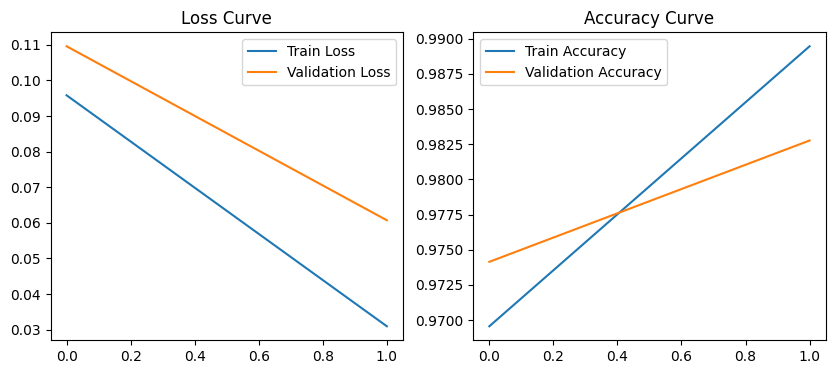

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

In [ ]:
def enable_dropout(model): # Function to enable dropout layers in a model
    for m in model.modules(): # Iterate through all modules in the model
        if isinstance(m, nn.Dropout): # If the module is a Dropout layer
            m.train() # Set it to training mode, which enables dropout (even during evaluation phase)

def mc_dropout_predict(model, image, n_samples=20):
    model.eval()
    enable_dropout(model)

    preds = []

    for _ in range(n_samples):
        with torch.no_grad():
            output = model(image)
            prob = torch.softmax(output, dim=1)
            preds.append(prob.cpu().numpy())

    preds = np.array(preds)

    mean_pred = preds.mean(axis=0)
    variance = preds.var(axis=0)

    return mean_pred, variance


In [ ]:
def predictive_entropy(probs):
    return -np.sum(probs * np.log(probs + 1e-10))

In [ ]:
class GradCAM: # Define the GradCAM class for generating saliency maps
    def __init__(self, model, target_layer):
        self.model = model # Store the model
        self.target_layer = target_layer # Store the target convolutional layer for CAM
        self.gradients = None # To store gradients
        self.activations = None # To store activations

        target_layer.register_forward_hook(self.save_activation) # Register a hook to save activations of the target layer
        target_layer.register_full_backward_hook(self.save_gradient) # Register a hook to save gradients flowing through the target layer

    def save_activation(self, module, input, output):
        self.activations = output # Save the output (activations) of the target layer

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0] # Save the gradients of the output with respect to the target layer's activations

    def generate(self, input_tensor, class_idx):
        self.model.zero_grad() # Zero all model gradients
        outputs = self.model(input_tensor) # Perform a forward pass
        loss = outputs[:, class_idx] # Get the score for the predicted class
        loss.backward() # Perform backpropagation to compute gradients

        grads = self.gradients # Retrieve saved gradients
        acts = self.activations # Retrieve saved activations

        weights = grads.mean(dim=(2, 3), keepdim=True) # Compute neuron importance weights by global average pooling gradients
        cam = (weights * acts).sum(dim=1) # Compute CAM by multiplying weights with activations and summing across channels

        cam = torch.relu(cam) # Apply ReLU to CAM to only keep positive contributions
        cam = cam - cam.min() # Normalize CAM to be between 0 and 1 (min-max scaling)
        cam = cam / (cam.max() + 1e-8) # Add a small epsilon to prevent division by zero

        return cam.detach().cpu().numpy()[0] # Detach from graph, move to CPU, convert to NumPy, and return

In [ ]:
gradcam = GradCAM(model, model.layer4[-1]) # Initialize GradCAM with the trained model and the last layer of ResNet block 4
uncertainty_threshold = 0.55   # Define an uncertainty threshold for flagging predictions (adjust if needed)

def diagnose_image(image_path): # Function to diagnose a single image
    img = Image.open(image_path).convert("RGB") # Open the image and convert to RGB format
    input_tensor = transform(img).unsqueeze(0) # Apply transformations and add a batch dimension

    # Corrected: Pass input_tensor to device and use n_samples. Also unpack mean_pred for probabilities.
    mean_pred_probs, variance = mc_dropout_predict(model, input_tensor.to(device), n_samples=30) # Get prediction probabilities and uncertainty (variance)

    # Calculate entropy from the mean probabilities
    entropy = predictive_entropy(mean_pred_probs[0]) # Calculate entropy from the first sample's mean probabilities

    pred_class = int(np.argmax(mean_pred_probs[0])) # Get the index of the predicted class
    pred_label = class_names[pred_class] # Get the label of the predicted class
    confidence = float(mean_pred_probs[0][pred_class]) # Get the confidence for the predicted class

    cam = gradcam.generate(input_tensor.to(device), pred_class) # Generate the Grad-CAM heatmap for the predicted class

    img_resized = img.resize((224, 224)) # Resize the original image for display
    img_np = np.array(img_resized) / 255.0 # Convert image to NumPy array and normalize for display
    # cam_resized = np.uint8(255 * cam) # This variable was defined but not used, can be removed if not needed for display elsewhere

    plt.figure(figsize=(10, 4)) # Create a figure for plotting

    plt.subplot(1, 3, 1) # First subplot: original X-ray
    plt.imshow(img_resized, cmap="gray") # Display the resized image
    plt.title("Input X-ray") # Set title
    plt.axis("off") # Turn off axes

    plt.subplot(1, 3, 2) # Second subplot: Grad-CAM heatmap
    plt.imshow(cam, cmap="jet") # Display the heatmap
    plt.title("Grad-CAM Heatmap") # Set title
    plt.axis("off") # Turn off axes

    plt.subplot(1, 3, 3) # Third subplot: overlay of image and heatmap
    plt.imshow(img_resized) # Display the resized image
    plt.imshow(cam, cmap="jet", alpha=0.5) # Overlay the heatmap with transparency
    plt.title("Explainable Overlay") # Set title
    plt.axis("off") # Turn off axes

    plt.show() # Display the plots

    print("========== AI Diagnosis Report ==========") # Print report header
    print("Prediction:", pred_label) # Print predicted label
    print("Confidence:", round(confidence, 4)) # Print confidence
    print("Uncertainty (Entropy):", round(float(entropy), 4)) # Print entropy as uncertainty

    if entropy > uncertainty_threshold: # Check if uncertainty is above the threshold
        print("⚠️ FLAGGED: Low reliability — Refer to radiologist.") # Flag for low reliability
    else:
        print("✅ Reliable prediction — Can support clinician decision.") # Indicate reliable prediction


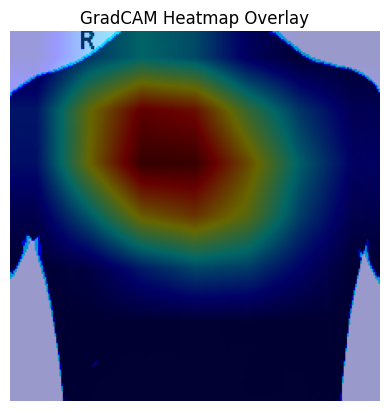

In [ ]:
import cv2
import matplotlib.pyplot as plt

img, label = test_data[0]

input_tensor = img.unsqueeze(0).to(device)

# Get the model's prediction for the image
model.eval() # Set model to evaluation mode
with torch.no_grad():
    output = model(input_tensor)
    _, pred_class = torch.max(output, 1)

# Generate heatmap using the predicted class
heatmap = gradcam.generate(input_tensor, pred_class.item())

img_np = img.permute(1,2,0).numpy()

# Ensure img_np is in the correct range for overlay (0-255) if it was normalized
# Convert img_np back to 0-255 if it's currently 0-1
if img_np.max() <= 1.0:
    img_np = (img_np * 255).astype(np.uint8)

heatmap = cv2.resize(heatmap, (224,224))
heatmap = cv2.applyColorMap(np.uint8(255*heatmap), cv2.COLORMAP_JET)

# Blending for visualization. Ensure data types are consistent.
# Convert img_np to 3 channels if it's grayscale for overlay with colormapped heatmap
if img_np.shape[2] == 1:
    img_np = cv2.cvtColor(img_np, cv2.COLOR_GRAY2BGR)

overlay = cv2.addWeighted(np.uint8(img_np), 0.6, heatmap, 0.4, 0)

plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title("GradCAM Heatmap Overlay")
plt.axis("off")
plt.show()

Testing image: chest_xray_data/chest_xray/test/NORMAL/IM-0001-0001.jpeg


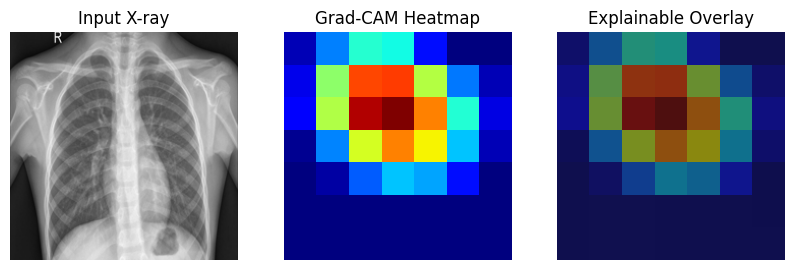

========== AI Diagnosis Report ==========
Prediction: NORMAL
Confidence: 0.9782
Uncertainty (Entropy): 0.1049
✅ Reliable prediction — Can support clinician decision.


In [ ]:
test_img_path = test_data.samples[0][0] # Get the file path of the first image in the test dataset
print("Testing image:", test_img_path) # Print the path of the image being tested

diagnose_image(test_img_path) # Call the diagnose_image function with the selected test image

In [ ]:
test_loss, test_acc = evaluate(model, test_loader, device) # Evaluate the model on the test dataset
print("Final Test Accuracy:", test_acc) # Print the final test accuracy

Evaluating: 100%|██████████| 20/20 [00:12<00:00,  1.64it/s]

Final Test Accuracy: 0.8317307692307692


In [ ]:
all_probs = []
all_labels = []
all_preds = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        all_probs.extend(probs[:,1].cpu().numpy())
        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())

In [ ]:
uncertainty_threshold = 0.15

flags = []
correct = []

for prob, label, pred in zip(all_probs, all_labels, all_preds):

    entropy = predictive_entropy(np.array([1-prob, prob]))

    flag = entropy > uncertainty_threshold

    flags.append(flag)
    correct.append(pred == label)

flags = np.array(flags)
correct = np.array(correct)

flagged_wrong = np.sum(flags & (~correct))
flagged_total = np.sum(flags)

print("Flagged samples:", flagged_total)
print("Wrong predictions among flagged:", flagged_wrong)

Flagged samples: 80
Wrong predictions among flagged: 39


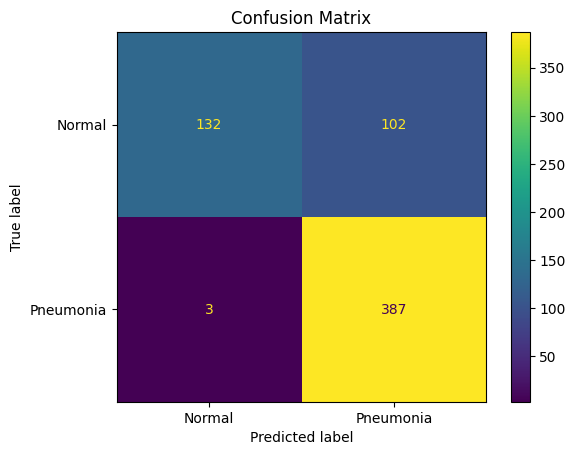

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Normal","Pneumonia"])

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import numpy as np # Import NumPy for numerical operations
import torch # Import PyTorch
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report # Import various metrics from scikit-learn

model.eval() # Set the model to evaluation mode

all_labels = [] # List to store all true labels
all_preds = [] # List to store all predicted labels
all_probs = [] # List to store all prediction probabilities (for the positive class)

with torch.no_grad(): # Disable gradient calculation
    for inputs, labels in test_loader:   # Iterate over batches in the test loader
        inputs = inputs.to(device) # Move inputs to the specified device
        labels = labels.to(device) # Move labels to the specified device

        outputs = model(inputs)                  # Get raw outputs (logits) from the model
        probs = torch.softmax(outputs, dim=1)    # Convert logits to probabilities using softmax

        preds = torch.argmax(probs, dim=1) # Get the predicted class by finding the index of the max probability

        all_labels.extend(labels.cpu().numpy()) # Store true labels (converted to NumPy array on CPU)
        all_preds.extend(preds.cpu().numpy()) # Store predicted labels (converted to NumPy array on CPU)
        all_probs.extend(probs[:, 1].cpu().numpy())  # Store probability of class 1 (PNEUMONIA) (converted to NumPy array on CPU)

all_labels = np.array(all_labels) # Convert list of true labels to NumPy array
all_preds  = np.array(all_preds) # Convert list of predicted labels to NumPy array
all_probs  = np.array(all_probs) # Convert list of probabilities to NumPy array

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds) # Calculate the confusion matrix
tn, fp, fn, tp = cm.ravel() # Unpack True Negative, False Positive, False Negative, True Positive

# Metrics
precision = precision_score(all_labels, all_preds) # Calculate precision
recall    = recall_score(all_labels, all_preds)   # Calculate recall (sensitivity)
f1        = f1_score(all_labels, all_preds) # Calculate F1-score

specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0 # Calculate specificity

# AUC-ROC
auc = roc_auc_score(all_labels, all_probs) # Calculate Area Under the Receiver Operating Characteristic Curve

print("========== Medical Evaluation Metrics ==========") # Print header for metrics
print("Confusion Matrix:\n", cm) # Print the confusion matrix
print(f"Precision:   {precision:.4f}") # Print precision
print(f"Recall/Sens: {recall:.4f}") # Print recall/sensitivity
print(f"Specificity: {specificity:.4f}") # Print specificity
print(f"F1-score:    {f1:.4f}") # Print F1-score
print(f"AUC-ROC:     {auc:.4f}") # Print AUC-ROC score

print("\nClassification Report:\n") # Print header for classification report
print(classification_report(all_labels, all_preds, target_names=class_names)) # Print a comprehensive classification report

========== Medical Evaluation Metrics ==========
Confusion Matrix:
 [[132 102]
 [  3 387]]
Precision:   0.7914
Recall/Sens: 0.9923
Specificity: 0.5641
F1-score:    0.8805
AUC-ROC:     0.9264

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.98      0.56      0.72       234
   PNEUMONIA       0.79      0.99      0.88       390

    accuracy                           0.83       624
   macro avg       0.88      0.78      0.80       624
weighted avg       0.86      0.83      0.82       624



## Evaluation Parameters

The proposed solution is evaluated using medical and ML metrics.

**Performance Metrics**
- Accuracy
- Precision
- Recall (Sensitivity)
- Specificity
- F1 Score
- AUC-ROC

**Uncertainty Metrics**
- Predictive Entropy
- Variance (MC Dropout)

**Explainability**
- Grad-CAM heatmap visualization
- Heatmap validity check

**Reliability Analysis**
- Flagged predictions based on uncertainty
- Analysis of flagged vs incorrect predictions